In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
import torch
import random
import numpy as np
import torch.nn as nn
from training.utils import utils
from training.utils.utilities import batch_PSNR
from models.grad_network import WCvxConvNet
from cupyx.profiler import benchmark

# use cmap = 'gray' always with plt
plt.rc('image', cmap='gray')

torch.set_grad_enabled(False)

In [2]:
model_name = 'WCRR-CNN_f_30_b_5_multispline'
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
PATH = f'trained_models/{model_name}/checkpoints/checkpoint.pth'
infos = torch.load(PATH)
config = infos['config']

model = WCvxConvNet(config['multi_convolution'], config['training_options'], config['spline_scaling'])
model.load_state_dict(infos['state_dict'], strict=False)
model = model.to(device)

L_R = model.grad_lipschitz()

print(f'L_R = {L_R}')

L_R = 62.7767333984375


In [3]:
v_test = np.ones((500,500,500))
v_shape = v_test.shape



In [4]:
def grad_subvolume(model, x, sigma=None, N_subvolumes=1):
            
    """ Gradient of the loss at location x. Update conv.L before if needed."""
    # first multi convolution layer
    grad = torch.zeros_like(x)
    with torch.no_grad():
        for i in range(N_subvolumes):
            # Dimensions are (batch, channels, depth, height, width)
            x_sub = x[:, :, :, i * x.shape[3] // N_subvolumes : (i + 1) * x.shape[3] // N_subvolumes, :]
            grad_sub = model.grad(x_sub, sigma=sigma)
            grad[:, :, :, i * x.shape[3] // N_subvolumes : (i + 1) * x.shape[3] // N_subvolumes, :] = grad_sub

    return(grad)

In [5]:
#model = model.to('cpu')
def spectral_norm(model):
    u = torch.randn(1, 1, 256, 256, 256, device=device)
    u = u / torch.norm(u)
    with torch.no_grad():
        for k in range(1000):
            v = model.conv(u)   
            v = v / torch.norm(v)
            u = model.conv.transpose(v)
            u = u / torch.norm(u)
            print(k)

    u = model.conv.transpose(model.conv(u))
    return u.norm()

In [10]:
impulses = model.impulses.cpu().numpy()
print(impulses.shape)

(64, 1, 7, 7, 7)


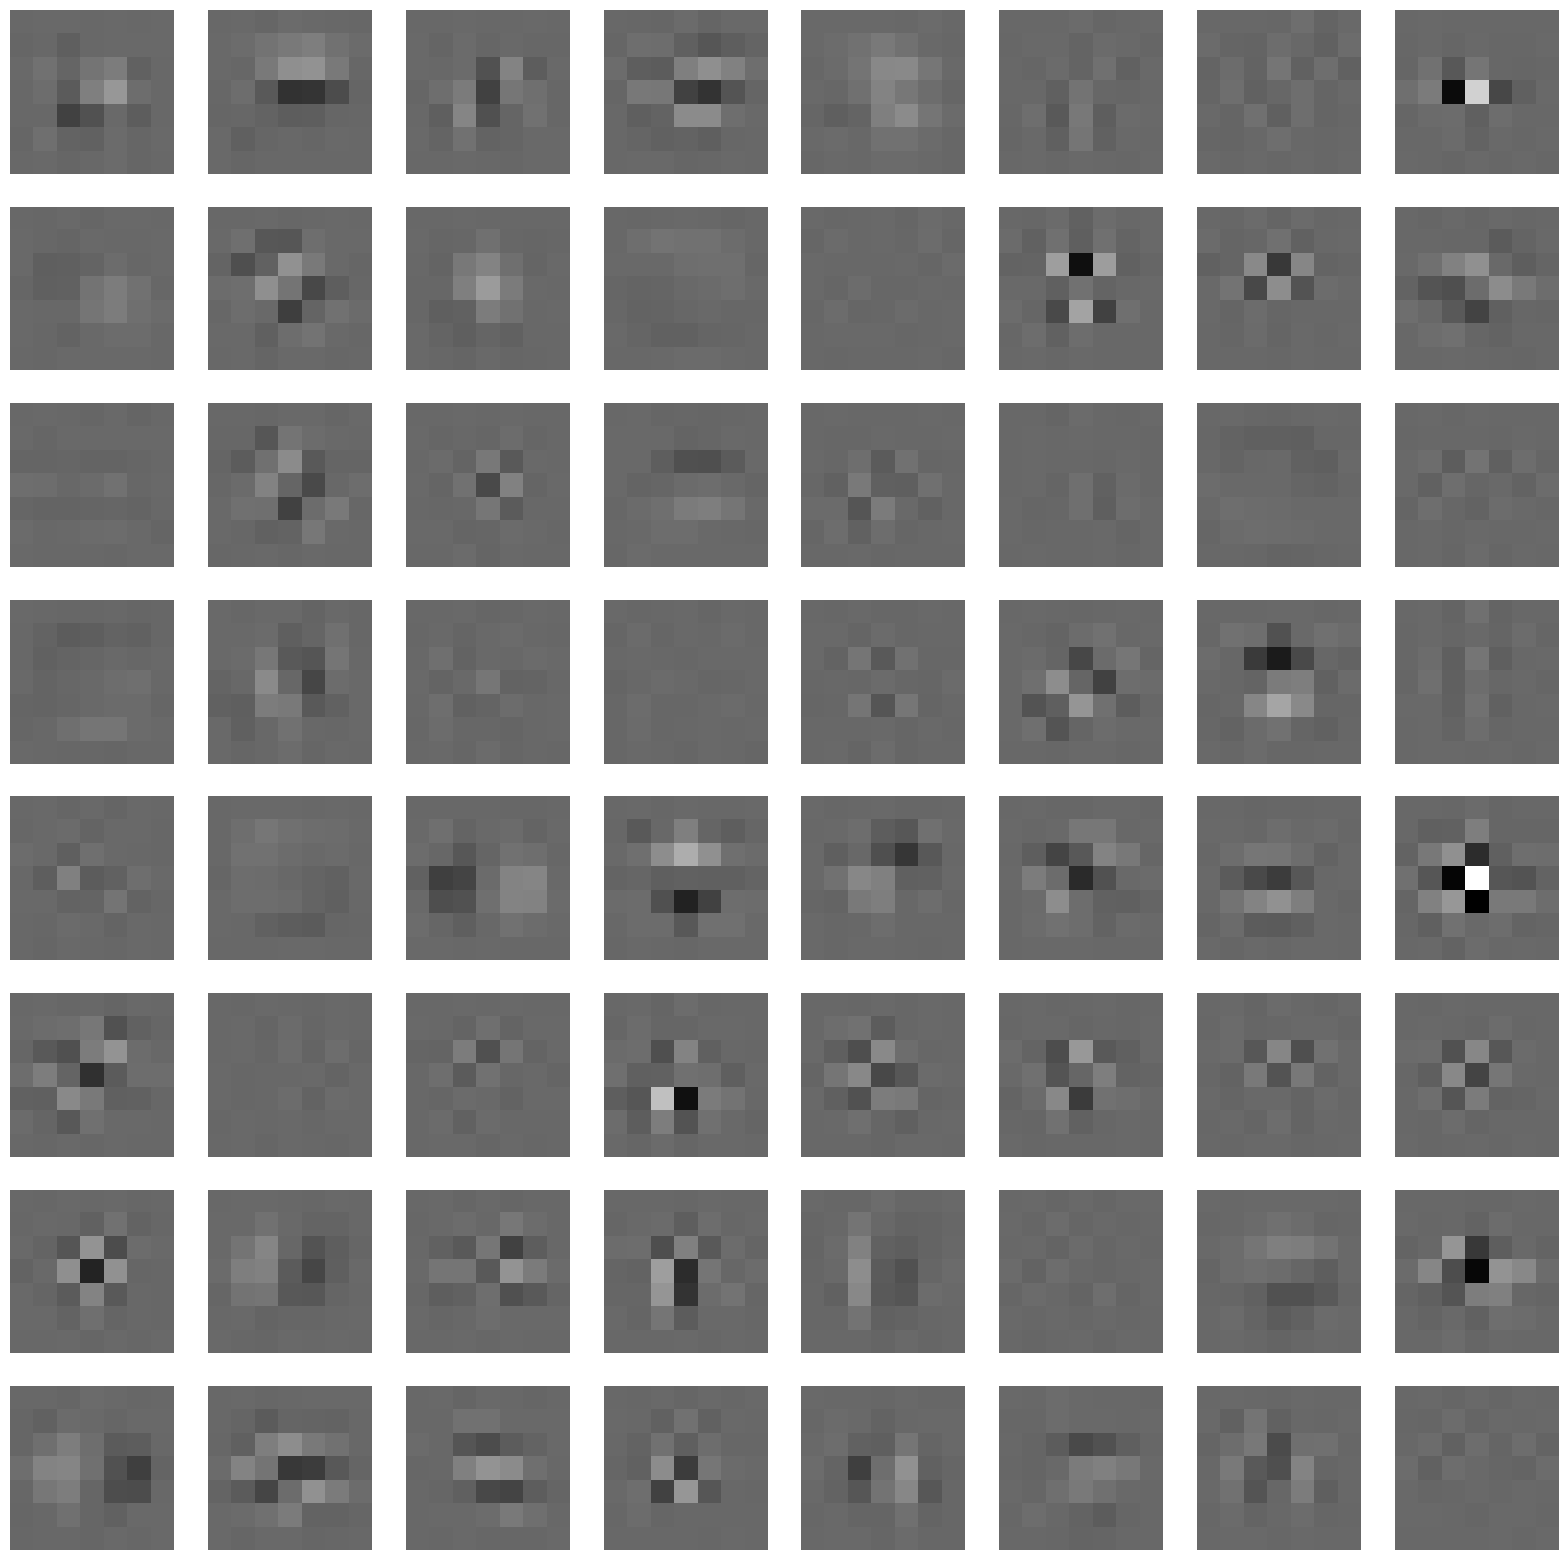

In [13]:
# 64 3D impulse response of size 7x7x7 : impulses has shape (64, 1, 7, 7, 7)

fig, axs = plt.subplots(8, 8, figsize=(20, 20))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(impulses[i*8+j, 0, :, 3, :], vmin = np.min(impulses), vmax = np.max(impulses))
        axs[i, j].axis('off')
plt.show()

TypeError: Invalid shape (7,) for image data

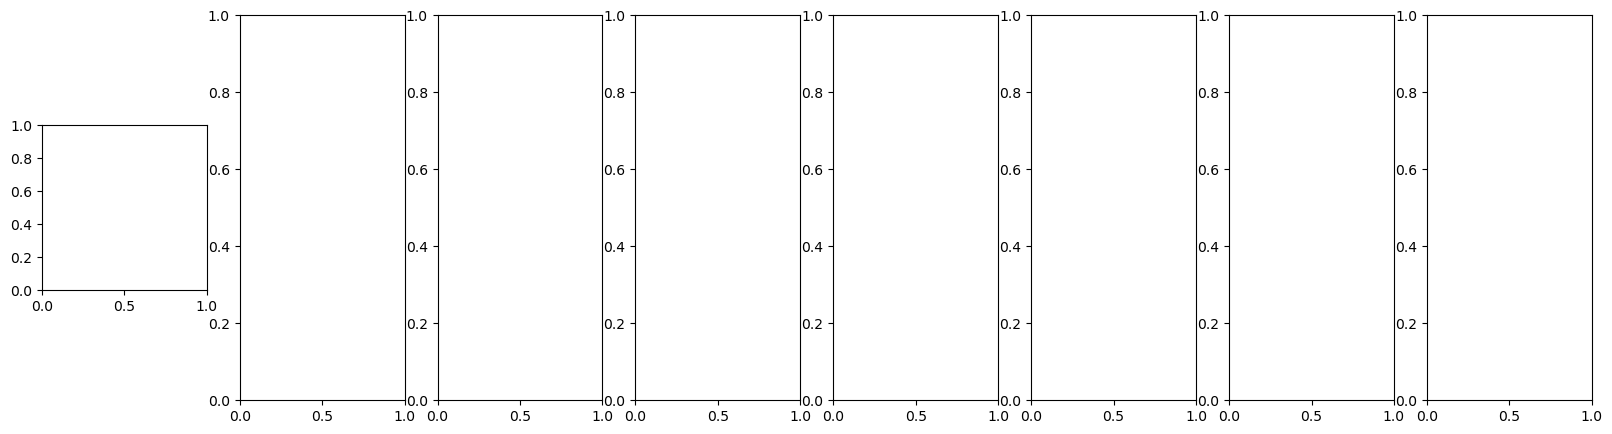

In [6]:
v_test = torch.rand(1, 1, 200, 200, 200).to(device)
sigma_ = 30.
sigma = torch.tensor(sigma_).repeat(1, 64, 1, 1, 1).to(device)
#res = model.grad_split(v_test, sigma=sigma, split = 8)
model.grad_split(v_test, sigma, 8)

In [ ]:

print(benchmark(model.grad_split, (v_test, sigma, 8), n_repeat=2))
print(benchmark(grad_subvolume, (model, v_test, sigma, 8), n_repeat=2))

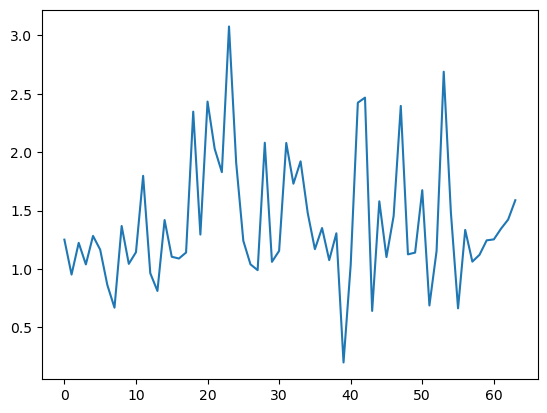

In [10]:
plt.plot(model.spline_scaling(sigma)[0,:,0,0,0].cpu().numpy())

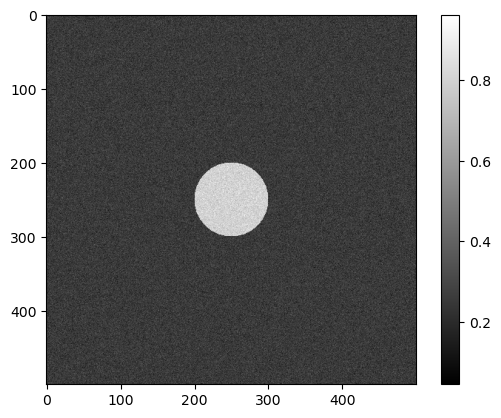

In [8]:
im = np.zeros((v_shape[0], v_shape[1], v_shape[2]))
XX, YY, ZZ = np.meshgrid(np.arange(v_shape[0]), np.arange(v_shape[1]), np.arange(v_shape[2]), indexing='ij')
im = np.where(np.sqrt((XX - v_shape[0]//2)**2 + (YY - v_shape[1]//2)**2 + (ZZ - v_shape[2]//2)**2) < 50, 1., 0.)
gt = im.copy()
im += np.random.randn(*im.shape)*0.08
im = (im - im.min())/(im.max() - im.min())
plt.figure()
plt.imshow(im[v_shape[0]//2])
plt.colorbar()
plt.show()


In [9]:
im = torch.tensor(im).to(device).float()
im = im.reshape(1, 1, v_shape[0], v_shape[1], v_shape[2])
y = im

print(y.shape)

torch.Size([1, 1, 500, 500, 500])


In [10]:
# Denoising
L_R = 116
N_iter = 100
reg = 20

residuals = []
import time 

with torch.no_grad():
    for i in range(N_iter):

        res  = grad_subvolume(model, im, sigma=sigma, N_subvolumes=8)
        #res = model.grad_split(im, sigma=sigma, split = 8)

        im_next = im - ((im-y) + reg*res)/(reg*L_R + 1)

        residuals.append((torch.linalg.norm(im_next - im)/torch.linalg.norm(im)).item())
        
        im = im_next
        #start = time.time()
        
        #print('Time for residuals:', time.time() - start)
        print(i, residuals[-1])

torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
0 0.008981806226074696
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
1 0.009172194637358189
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
2 0.009358441457152367
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
torch.Size([1, 64, 1, 1, 1])
3 0

In [12]:
im_denoised = im.cpu().detach().numpy().squeeze()

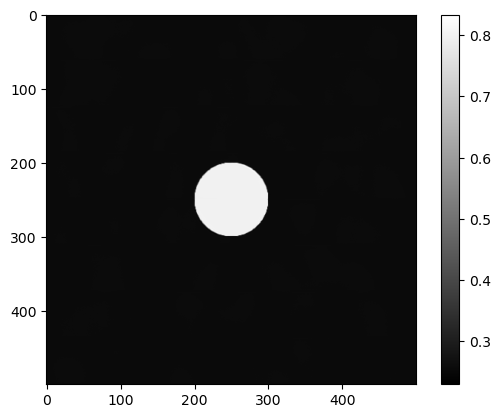

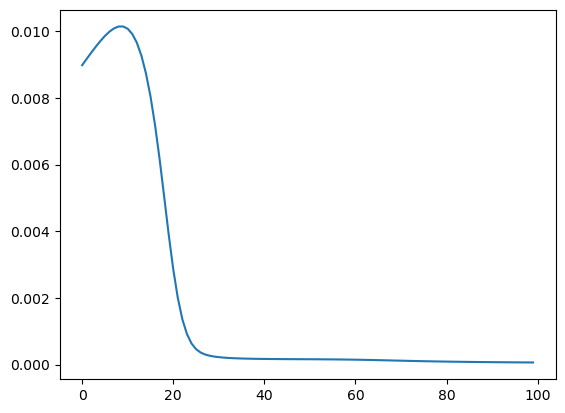

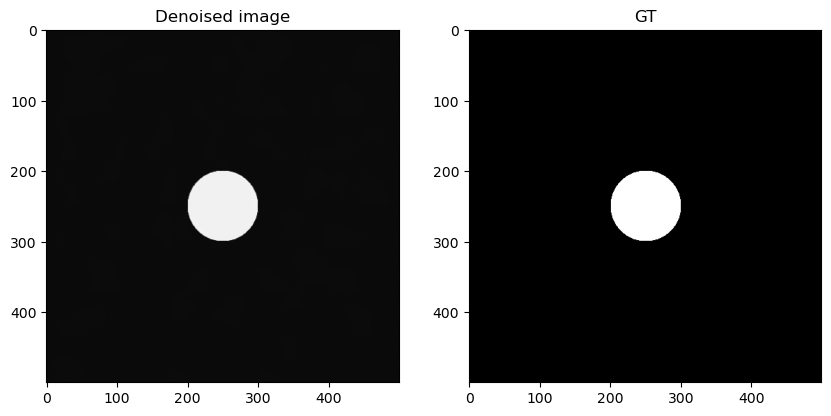

In [13]:
plt.figure()
plt.imshow(im_denoised[v_shape[0]//2])
# colorbar
plt.colorbar()

plt.figure()
plt.plot(residuals)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(im_denoised[v_shape[0]//2])
ax[0].set_title('Denoised image')
ax[1].imshow(gt[v_shape[0]//2])
ax[1].set_title('GT')
plt.show()